In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Mutual Information and Representation Learning

The entropies and divergences of that section score
one distribution at a time. This section asks the question that powers modern
representation learning: how much information do *two* random variables share?
The answer, *mutual information*, is the engine behind contrastive and
self-supervised training: SimCLR, CPC, and CLIP-style dual encoders
[@Chen.Kornblith.Norouzi.ea.2020; @Oord.Li.Vinyals.2018; @radford2021learning]
are, formally, mutual-information maximizers, and the InfoNCE loss they
minimize is a *lower bound* on mutual information. The same section also
carries a warning: certifying a large mutual information from samples is
provably hard (no estimator can certify more than about $\log N$ nats from
$N$ samples), so these objectives must be read as training signals, not as
measurements. We build the quantity and its calculus first (including the
*data-processing inequality*, the theorem that says representations can only
lose information), then confront the estimation barrier, then derive the
variational bounds and InfoNCE, and close with the information bottleneck and
an account of what mutual information can and cannot tell you.

As in that section, **we work in nats** (natural
logarithm) throughout, flagging the occasional conversion to bits explicitly;
recall $1 \textrm{ bit} = \ln 2 \approx 0.693$ nats. We also lean on two
facts from that section without re-proving them: Gibbs' inequality
($D_{\textrm{KL}} \geq 0$ with equality iff the distributions agree) and the
decomposition $\textrm{CE} = H + D_{\textrm{KL}}$.

Most of this section is plain-NumPy probability; the deep-learning library
appears when we *train* a critic at the end of the variational-bounds
section.

In [1]:
%matplotlib inline
from d2l import torch as d2l
import torch
import numpy as onp  # plain NumPy for the probability demos
from scipy.special import digamma

## Mutual Information: Definitions and Properties

Throughout, $(X,Y)$ is a pair of random variables with joint distribution
$P_{X,Y}$ and marginals $P_X,P_Y$. We begin the entropy bookkeeping in the
discrete case. For continuous variables the same symbols denote differential
entropies only when the relevant integrals are finite; the KL definition of
mutual information below remains primary and avoids undefined differences such
as $\infty-\infty$. Everything we build answers one question:
what does observing $Y$ tell us about $X$?

### From One Variable to Two: Joint and Conditional Entropy

Entropy extends from one variable to a pair the obvious way. The *joint
entropy* of $(X, Y)$ is the average surprise of observing the pair,

$$H(X, Y) = -E_{(x, y) \sim P_{X,Y}} [\log p_{X, Y}(x, y)],$$

a sum over outcomes. The two extremes orient the discrete definition: if
$Y=X$, the pair carries no more information than either variable alone,
$H(X,Y)=H(X)$; if $X$ and $Y$ are independent, surprises add,
$H(X,Y)=H(X)+H(Y)$. Every discrete dependent pair sits between these bounds.
For a continuous $Y=X$, by contrast, the joint law lies on a lower-dimensional
diagonal, has no ordinary joint density with respect to area, and has infinite
mutual information; the discrete identity must not be transferred verbatim.

Often we care about a directed version of the question. Take $X$ to be the
pixels of an image and $Y$ its class label. The image is a complicated,
information-rich object, but once we have *seen* it, the label holds few
surprises: a legible digit already tells you which digit it is. The
*conditional entropy*

$$H(Y \mid X) = - E_{(x, y) \sim P_{X,Y}} [\log p(y \mid x)],$$

with $p(y \mid x) = p_{X,Y}(x, y)/p_X(x)$, measures exactly this residual:
the average surprise in $Y$ *after* $X$ is known. The three quantities are
linked by a bookkeeping identity.

**Proposition (chain rule for entropy).** *For discrete variables, or for
continuous variables when the displayed entropies are finite,
$H(X,Y)=H(X)+H(Y\mid X)$.*

**Proof.** Inside the expectation defining $H(X,Y)$, factor the joint density:
$\log p_{X,Y}(x,y) = \log p_X(x) + \log p(y \mid x)$. Taking
$-E_{(x,y) \sim P_{X,Y}}$ of both sides turns the left side into $H(X,Y)$ and
the two right-hand terms into $H(X)$ and $H(Y \mid X)$.
$\blacksquare$

Read it as an accounting statement: the total information in the pair is the
information in $X$ plus whatever $Y$ adds once $X$ is known.

Let's make the definitions concrete on a $2 \times 2$ joint distribution.
Take

$$
p_{X,Y} = \begin{pmatrix} 0.1 & 0.4 \\ 0.2 & 0.3 \end{pmatrix},
$$

with rows indexing $x \in \{0, 1\}$ and columns $y \in \{0, 1\}$; the entries
sum to $1$ as a joint p.m.f. must. The marginals come *from the joint* by
summing rows and columns: $p_X = (0.5, 0.5)$ and $p_Y = (0.3, 0.7)$. From the
definitions, $H(X,Y) \approx 1.2799$ nats, $H(X) = \ln 2 \approx 0.6931$
nats, $H(Y) \approx 0.6109$ nats, and the chain rule predicts
$H(Y \mid X) = H(X,Y) - H(X) \approx 0.5867$ nats, which the direct
definition the equation confirms.

In [2]:
p_xy = onp.array([[0.1, 0.4],
                  [0.2, 0.3]])           # a valid joint: entries sum to 1
p_x, p_y = p_xy.sum(axis=1), p_xy.sum(axis=0)  # marginals FROM the joint

entropy = lambda p: float(-(p * onp.log(p)).sum())
H_xy, H_x, H_y = entropy(p_xy), entropy(p_x), entropy(p_y)
# Conditional entropy directly: p(y|x) = p(x,y) / p(x), weighted by p(x,y)
H_y_given_x = float(-(p_xy * onp.log(p_xy / p_x[:, None])).sum())

print(f'marginals: p_x = {p_x}, p_y = {p_y}')
print(f'H(X,Y) = {H_xy:.4f}, H(X) = {H_x:.4f}, H(Y) = {H_y:.4f} nats')
print(f'H(Y|X) = {H_y_given_x:.4f} = H(X,Y) - H(X) = {H_xy - H_x:.4f} nats')

marginals: p_x = [0.5 0.5], p_y = [0.3 0.7]
H(X,Y) = 1.2799, H(X) = 0.6931, H(Y) = 0.6109 nats
H(Y|X) = 0.5867 = H(X,Y) - H(X) = 0.5867 nats


### Mutual Information as a Divergence from Independence

The conditional entropy measured what $Y$ keeps *to itself*; we want what
$X$ and $Y$ *share*. The definition needs no entropy at all. If $X$ and $Y$
were independent, their joint
distribution would be the product of marginals $P_X \otimes P_Y$, with density
$p_X(x)\,p_Y(y)$. The *mutual information* is the KL divergence from that
hypothetical independent world to the actual joint:

$$I(X; Y) = D_{\textrm{KL}}\!\left(P_{X,Y} \,\|\, P_X \otimes P_Y\right) = E_{(x, y) \sim P_{X,Y}} \left[ \log\frac{p_{X, Y}(x, y)}{p_X(x)\, p_Y(y)} \right].$$

In words: mutual information is *how far the pair is from being independent*,
measured in the same units as every other quantity in this chapter. (The
semicolon in $I(X; Y)$ is the standard notation, distinguishing the two
arguments from a single joint object.) The definition presumes the joint has
a density with respect to the product of the marginals; when it does not,
for instance when $Y = f(X)$ is a deterministic function of a continuous
$X$, the divergence, and hence $I(X; Y)$, is infinite. Symmetry and
nonnegativity are immediate from the divergence form, and the entropy
identities follow by expanding the logarithm.

**Proposition (properties of mutual information).** *For any pair $(X,Y)$,
$I(X;Y)$ is symmetric and non-negative, with equality if and only if $X$ and
$Y$ are independent. When the relevant discrete or differential entropies are
finite, it also satisfies*

$$
I(X;Y)=H(X)+H(Y)-H(X,Y)=H(X)-H(X\mid Y)=H(Y)-H(Y\mid X).
$$

**Proof.** When the entropy terms are finite, expand the logarithm in
the equation:

$$
I(X; Y)
= E\left[\log p_{X,Y}(x,y)\right] - E\left[\log p_X(x)\right] - E\left[\log p_Y(y)\right]
= -H(X,Y) + H(X) + H(Y).
$$

Substituting the chain rule $H(X,Y) = H(Y) + H(X \mid Y)$ gives
$I(X;Y) = H(X) - H(X \mid Y)$, and the symmetric substitution gives
$H(Y) - H(Y \mid X)$. Symmetry is immediate from
the equation, whose density ratio is unchanged when $X$ and $Y$
are swapped. Nonnegativity is Gibbs' inequality
(that section) applied to the two distributions
$P_{X,Y}$ and $P_X \otimes P_Y$: the divergence is non-negative, and zero
exactly when they coincide, i.e., when
$p_{X,Y}(x,y) = p_X(x)\,p_Y(y)$ everywhere, which is the definition of
independence. $\blacksquare$

The identities have a picture, the figure: draw $H(X)$ and
$H(Y)$ as overlapping disks. The overlap is $I(X;Y)$, the crescents are the
conditional entropies, the union is the joint entropy, and each identity in
claim 1 is one way of reading off the overlap's area. The picture also
explains the directed reading: $I(X;Y) = H(X) - H(X \mid Y)$ is the
*reduction in surprise* about $X$ that observing $Y$ buys.

![Mutual information $I(X;Y)$ as the overlap of the entropies $H(X)$ and $H(Y)$: the crescents are the conditional entropies $H(X\mid Y)$ and $H(Y\mid X)$, the union is the joint entropy $H(X,Y)$, and the three equivalent expressions for $I(X;Y)$ follow by reading off the areas.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-it-mi-overlap.svg)

Back to the worked example. With marginals computed from the joint, the
divergence form the equation and the entropy identity must
return the same number, and they do: $I(X;Y) \approx 0.0242$ nats
($\approx 0.035$ bits after dividing by $\ln 2$). The pair is *barely*
dependent: the joint $\begin{smallmatrix}0.1 & 0.4\\0.2 & 0.3\end{smallmatrix}$
is close to the product of its marginals
$\begin{smallmatrix}0.15 & 0.35\\0.15 & 0.35\end{smallmatrix}$, and mutual
information quantifies the gap.

In [3]:
def mutual_information(p_xy):
    """I(X;Y) of a discrete joint p.m.f., in nats."""
    p_x = p_xy.sum(axis=1, keepdims=True)   # marginals from the joint
    p_y = p_xy.sum(axis=0, keepdims=True)
    return float((p_xy * onp.log(p_xy / (p_x * p_y))).sum())

mi_kl = mutual_information(p_xy)            # divergence form
mi_ent = H_x + H_y - H_xy                    # entropy identity
print(f'I(X;Y) = {mi_kl:.4f} nats (KL form) '
      f'= {mi_ent:.4f} nats (entropy identity)')
print(f'       = {mi_kl / onp.log(2):.4f} bits')

I(X;Y) = 0.0242 nats (KL form) = 0.0242 nats (entropy identity)
       = 0.0349 bits


### The Gaussian Anchor

For continuous variables the canonical worked example is the bivariate
Gaussian, where mutual information has a closed form that we will use as
*ground truth* for every estimator in the rest of this section.

**Proposition (Gaussian mutual information).** *If $(X, Y)$ is bivariate
Gaussian with correlation coefficient $\rho$, then*

$$I(X; Y) = -\tfrac{1}{2} \log\left(1 - \rho^2\right).$$

**Proof.** Mutual information is invariant under separate invertible maps of
$X$ and of $Y$ (proved in the next subsection), so we may standardize both
variables and take

$$
\Sigma = \begin{pmatrix} 1 & \rho \\ \rho & 1 \end{pmatrix},
\qquad \det \Sigma = 1 - \rho^2.
$$

For a standard Gaussian the differential entropy is
$h(X) = h(Y) = \tfrac{1}{2}\log(2\pi e)$, a value computed explicitly inside
the maximum-entropy proof of that section; the
same integration against the bivariate density gives
$h(X, Y) = \tfrac{1}{2}\log\left((2\pi e)^2 \det\Sigma\right)$. The entropy
identity of claim 1 carries over: joint and conditional differential
entropies are the same formulas with integrals in place of sums, and the
chain-rule algebra never used discreteness. It gives

$$
I(X; Y) = h(X) + h(Y) - h(X, Y)
= \log(2\pi e) - \tfrac{1}{2}\log\left((2\pi e)^2 (1 - \rho^2)\right)
= -\tfrac{1}{2}\log(1 - \rho^2).
$$

Each differential entropy individually depends on the coordinates (recall the
caveat of that section: differential entropy can even
be negative), but the offending terms cancel in the combination: mutual
information is a *relative* quantity. $\blacksquare$

Read the limits: at $\rho = 0$ the variables are independent (for Gaussians,
uncorrelated implies independent) and $I = 0$; as $\rho \to \pm 1$ the joint
density collapses onto a line, $Y$ determines $X$, and $I \to \infty$. In
between, the formula gives concrete targets: $\rho = 0.5$ carries
$\approx 0.144$ nats, $\rho = 0.9$ carries $\approx 0.830$ nats, and
$\rho = 0.99$ carries $\approx 1.96$ nats.

Let's verify the equation empirically with the simplest
estimator there is: bin the samples into a 2-D histogram and apply the
discrete formula to the bin frequencies.

rho = 0.00: binned = 0.0027, closed form = -0.0000 nats
rho = 0.30: binned = 0.0504, closed form = 0.0472 nats
rho = 0.60: binned = 0.2235, closed form = 0.2231 nats
rho = 0.90: binned = 0.8111, closed form = 0.8304 nats
rho = 0.99: binned = 1.7829, closed form = 1.9585 nats


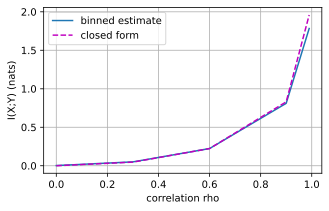

In [4]:
def gauss_pair(rng, rho, n):
    """n samples of a standard bivariate Gaussian with correlation rho."""
    x = rng.standard_normal(n)
    y = rho * x + onp.sqrt(1 - rho**2) * rng.standard_normal(n)
    return x, y

def binned_mi(x, y, bins=40):
    """Plug-in MI estimate from a 2-D histogram, in nats."""
    counts, _, _ = onp.histogram2d(x, y, bins=bins)
    p = counts / counts.sum()
    p_x, p_y = p.sum(axis=1, keepdims=True), p.sum(axis=0, keepdims=True)
    mask = p > 0
    return float((p[mask] * onp.log(p[mask] / (p_x * p_y)[mask])).sum())

rng = onp.random.default_rng(42)
rhos = onp.array([0.0, 0.3, 0.6, 0.9, 0.99])
est = [binned_mi(*gauss_pair(rng, r, 200_000)) for r in rhos]
true = [-0.5 * onp.log(1 - r**2) for r in rhos]
for r, e, t in zip(rhos, est, true):
    print(f'rho = {r:4.2f}: binned = {e:.4f}, closed form = {t:.4f} nats')
d2l.plot(rhos, [onp.array(est), onp.array(true)], 'correlation rho',
         'I(X;Y) (nats)', legend=['binned estimate', 'closed form'],
         figsize=(5, 3))

With $200{,}000$ samples and a $40 \times 40$ grid, the histogram tracks the
closed form well at moderate correlation, but look closely at
$\rho = 0.99$: the estimate comes in at roughly $1.78$ nats against a truth
of $1.96$, missing about $0.18$ nats because the probability mass hides in a
ridge thinner than the bins. Even in *two* dimensions with abundant data,
the obvious estimator is already biased once the dependence is strong. The
second part of this section is about how much worse this gets.

### Pointwise Mutual Information

Mutual information is an *average*. The quantity being averaged in
the equation is interesting in its own right: the
*pointwise mutual information*

$$\textrm{pmi}(x, y) = \log\frac{p_{X, Y}(x, y)}{p_X(x)\, p_Y(y)}$$

compares how often the specific pair $(x, y)$ occurs to how often it *would*
occur if $X$ and $Y$ were independent. Positive pmi means the outcomes attract
(they co-occur more than chance predicts); negative pmi means they repel; and
$I(X;Y) = E[\textrm{pmi}(x,y)]$ is the average attraction.

Pointwise mutual information is a classic workhorse of natural language
processing [@Church.Hanks.1990], where it separates genuine
*collocations* from words that merely co-occur because both are common. Here
is the effect in miniature. Suppose we count consecutive word pairs (bigrams)
in a small corpus and tally how often each of the first words *new*,
*machine*, *the* is followed by each of *york*, *learning*, *day*:

| count | york | learning | day |
| :-- | --: | --: | --: |
| **new** | 38 | 3 | 9 |
| **machine** | 1 | 46 | 3 |
| **the** | 11 | 21 | 168 |

The raw counts mislead: "the day" is by far the most frequent pair ($168$
occurrences against $38$ for "new york"), simply because *the* and *day* are
both frequent words. Pointwise mutual information corrects for the marginals.

In [5]:
counts = onp.array([[38., 3., 9.],     # new york / new learning / new day
                    [1., 46., 3.],     # machine ...
                    [11., 21., 168.]]) # the ...
first, second = ['new', 'machine', 'the'], ['york', 'learning', 'day']

p = counts / counts.sum()
p_w, p_c = p.sum(axis=1, keepdims=True), p.sum(axis=0, keepdims=True)
pmi = onp.log(p / (p_w * p_c))
for (i, j) in [(0, 0), (1, 1), (2, 2), (2, 0)]:
    print(f'pmi({first[i]}, {second[j]}) = {pmi[i, j]:6.3f} nats '
          f'(count {counts[i, j]:.0f})')
print(f'I(first; second) = {float((p * pmi).sum()):.4f} nats')

pmi(new, york) =  1.517 nats (count 38)
pmi(machine, learning) =  1.372 nats (count 46)
pmi(the, day) =  0.336 nats (count 168)
pmi(the, york) = -1.109 nats (count 11)
I(first; second) = 0.4146 nats


The ranking flips, exactly as a fluent speaker would rank the collocations:
"new york" scores $\textrm{pmi} \approx 1.52$ nats and "machine learning"
$\approx 1.37$, while the frequent-but-unremarkable "the day" manages only
$\approx 0.34$; the pair "the york" comes out *negative*
($\approx -1.11$ nats), occurring three times less often than independence
would predict. The table's overall mutual information, $\approx 0.41$ nats,
summarizes how strongly first words constrain second words on average. This
count-divide-and-log pattern (and its smoothed variants) underpins
classical word-association mining and survives inside modern embedding
methods, where factorizing a pmi matrix recovers word vectors
[@Levy.Goldberg.2014].

### Mutual Information as Nonlinear Correlation

How does mutual information relate to the correlation coefficient of
that section? Correlation detects *linear* dependence:
$\rho(X, Y) = 0$ does **not** imply independence, only the absence of a
linear trend. Mutual information detects *any* dependence: by claim 3 of the
properties proposition, $I(X; Y) = 0$ holds *if and only if* $X \perp Y$.
Two further properties sharpen the contrast.

**Proposition (reparameterization invariance).** *If $g$ and $h$ are
invertible maps (in the continuous case, smooth with smooth inverses), then
$I(g(X); h(Y)) = I(X; Y)$.*

**Proof.** For discrete variables, invertibility means $g$ and $h$ merely
relabel outcomes: the joint p.m.f. of $(g(X), h(Y))$ takes the same values as
that of $(X, Y)$, just at different labels, and the sum in
the equation is unchanged. For continuous variables, write
mutual information as the KL divergence
$D_{\textrm{KL}}(P_{X,Y} \| P_X \otimes P_Y)$ and apply the smooth change of
variables $(x, y) \mapsto (g(x), h(y))$: *both* densities in the ratio pick
up the same Jacobian factor $|g'(x)|^{-1} |h'(y)|^{-1}$, which cancels.
(Contrast differential entropy, where the uncancelled Jacobian is exactly why
it is coordinate-dependent; see that section.)
$\blacksquare$

Correlation enjoys no such invariance: it is preserved only by *affine* maps
(up to sign). So mutual information is the more principled notion of
dependence: it asks whether two variables are informative about each other
in *any* coordinates, not whether they happen to line up. A standard
counterexample makes both points at once: let $X \sim \mathcal{N}(0, 1)$ and
$Y = X^2 + 0.3\,\epsilon$ with independent noise
$\epsilon \sim \mathcal{N}(0,1)$. Then $\textrm{Cov}(X, Y) = E[X^3] = 0$ by
symmetry, so the correlation vanishes, yet $Y$ is nearly a function of $X$,
and the dependence is strong.

In [6]:
rng = onp.random.default_rng(0)
n = 200_000
x = rng.standard_normal(n)
y = x**2 + 0.3 * rng.standard_normal(n)    # zero correlation by symmetry

print(f'sample correlation rho = {onp.corrcoef(x, y)[0, 1]:+.4f}')
print(f'binned MI estimate     = {binned_mi(x, y):.4f} nats')
print(f'after x -> 2x + 3      = {binned_mi(2 * x + 3, y):.4f} nats')

sample correlation rho = -0.0028
binned MI estimate     = 0.9814 nats
after x -> 2x + 3      = 0.9814 nats


The correlation is numerically zero while the mutual information estimate is
about one nat, *more* shared information than the $\rho = 0.9$ Gaussian pair
above ($0.830$ nats). The third line checks invariance: an affine
reparameterization of $X$ leaves the estimate exactly unchanged (the
histogram bins stretch with the data, so even the bin counts are identical).
One caution for later: this invariance is also why mutual information is hard
to *estimate*: an estimator must implicitly cope with every
reparameterization of the data at once, and we will see in
that section that this costs dearly.

### Conditional Mutual Information and the Chain Rule

One more piece of calculus and the toolbox is complete. Just as entropy has a
conditional version, so does mutual information: the *conditional mutual
information*

$$I(X; Y \mid Z) = H(X \mid Z) - H(X \mid Y, Z)$$

is the information $X$ and $Y$ share *once $Z$ is already known*.
Equivalently, $I(X; Y \mid Z) = E_{z}\left[D_{\textrm{KL}}(P_{X,Y \mid z}
\,\|\, P_{X \mid z} \otimes P_{Y \mid z})\right]$: expanding each
conditional entropy as an expectation and collecting the logarithms into the
ratio $p_{X,Y \mid z}/(p_{X \mid z}\, p_{Y \mid z})$ repeats the algebra of
claim 1 under each conditional law. As an average of per-$z$ divergences it
inherits nonnegativity from Gibbs, with $I(X; Y \mid Z) = 0$ if and only if
$X$ and $Y$ are conditionally independent given $Z$. The chain rule then
splits joint information into sequential contributions.

**Proposition (chain rule for mutual information).** *For any $X, Y, Z$,*

$$
I(X; Y, Z) = I(X; Z) + I(X; Y \mid Z).
$$

**Proof.** Telescope with the entropy identities:

$$
I(X; Y, Z) = H(X) - H(X \mid Y, Z)
= \underbrace{H(X) - H(X \mid Z)}_{I(X;\, Z)}
+ \underbrace{H(X \mid Z) - H(X \mid Y, Z)}_{I(X;\, Y \mid Z)}.
\quad\blacksquare
$$

**Corollary (independent side information is free).** *If $W$ is independent
of the pair $(X, Y)$, then $I(X; (Y, W)) = I(X; Y)$.*

**Proof.** By the chain rule, $I(X; Y, W) = I(X; W) + I(X; Y \mid W)$. The
first term is zero since $W \perp X$. For the second, independence of $W$
from the pair means conditioning on $W$ changes neither $H(X)$ nor
$H(X \mid Y)$, so $I(X; Y \mid W) = I(X; Y)$. $\blacksquare$

The corollary is exactly the accounting we will need for InfoNCE in
that section, where a batch of independent "negative" samples
is appended to $Y$ and must add no information about $X$. The chain rule's
main consequence deserves its own subsection.

### The Data-Processing Inequality

Random variables $X, Y, Z$ form a *Markov chain*, written
$X \to Y \to Z$, when $Z$ depends on $(X, Y)$ only through $Y$:
$p(z \mid x, y) = p(z \mid y)$. This is the structure of *processing*: $Y$ is
computed from $X$ (a measurement, a feature map, a hidden layer), then $Z$ is
computed from $Y$ alone. Equivalently, $X$ and $Z$ are conditionally
independent given $Y$, i.e., $I(X; Z \mid Y) = 0$. The following one-line
theorem [@Cover.Thomas.1999] is the conservation law that governs it.

**Proposition (data-processing inequality).** *If $X \to Y \to Z$ is a
Markov chain, then*

$$
I(X; Z) \leq I(X; Y),
$$

*with equality if and only if $I(X; Y \mid Z) = 0$ (i.e., $X \to Z \to Y$ is
also a Markov chain).*

**Proof.** Expand $I(X; Y, Z)$ by the chain rule in both orders:

$$
I(X; Z) + I(X; Y \mid Z) = I(X; Y, Z) = I(X; Y) + I(X; Z \mid Y).
$$

The Markov property kills the last term, $I(X; Z \mid Y) = 0$, leaving
$I(X; Z) = I(X; Y) - I(X; Y \mid Z) \leq I(X; Y)$, since conditional mutual
information is non-negative. Equality holds exactly when
$I(X; Y \mid Z) = 0$. $\blacksquare$

No processing of $Y$, deterministic or random, clever or dumb, can
*increase* the information it carries about $X$. Three readings:

* **Representations only lose.** A network computes its representation
  layer-by-layer, $X \to Z_1 \to Z_2 \to \cdots$, so
  $I(X; Z_1) \geq I(X; Z_2) \geq \cdots$ and likewise
  $I(Y; Z_1) \geq I(Y; Z_2) \geq \cdots$ for a label $Y$ at the *input* end
  of the chain (since $Y \to X \to Z_\ell$ is Markov). Whatever label
  information the input lacks, no architecture can conjure; whatever a layer
  discards, no later layer recovers. This is the theorem that makes the
  information bottleneck of that section a
  sensible objective rather than wishful thinking.
* **Equality is achievable.** If $Z = g(Y)$ for an *invertible* $g$, then the
  chain runs both ways and $I(X; Z) = I(X; Y)$, consistent with the
  reparameterization invariance proved earlier. A many-to-one or noisy map may lose information, but it need not: a
  sufficient statistic can be noninvertible or noisy while preserving all the
  information about $X$. Equality in data processing is characterized by such
  sufficiency, not by invertibility alone.
* **A sufficient statistic is a lossless compression.** When equality holds
  with $Z$ much "smaller" than $Y$, the map has discarded only what was
  irrelevant to $X$: this is the information-theoretic reading of a
  sufficient statistic (that section).

One caution about scope. The data-processing inequality is a statement about
Markov chains, not about conditioning in general: conditioning can *create*
dependence, and $I(X; Y \mid Z) > I(X; Y)$ is perfectly possible: in the
extreme case of two independent fair bits with $Z$ their XOR, conditioning
turns zero dependence into a full $\ln 2$ nats (Exercise 6 works this out).
"Processing destroys information" is a theorem about the chain
$X \to Y \to Z$ alone; outside that structure, conditioning can raise or
lower dependence, as the XOR example shows.

Let's verify the bookkeeping numerically on the simplest nontrivial chain:
a fair bit $X$, flipped with probability $0.1$ to give $Y$, flipped again
with probability $0.2$ to give $Z$.

In [7]:
p_x = onp.array([0.5, 0.5])
K1 = onp.array([[0.9, 0.1], [0.1, 0.9]])   # p(y|x): flip w.p. 0.1
K2 = onp.array([[0.8, 0.2], [0.2, 0.8]])   # p(z|y): flip w.p. 0.2
p_xyz = p_x[:, None, None] * K1[:, :, None] * K2[None, :, :]

def cond_mi(p_abc):
    """I(A;B|C) for a joint array indexed [a, b, c], in nats."""
    p_ac, p_bc, p_c = p_abc.sum(1), p_abc.sum(0), p_abc.sum((0, 1))
    ratio = p_abc * p_c[None, None, :] / (p_ac[:, None, :] * p_bc[None, :, :])
    return float((p_abc * onp.log(ratio)).sum())

I_xy = mutual_information(p_xyz.sum(axis=2))           # I(X;Y)
I_xz = mutual_information(p_xyz.sum(axis=1))           # I(X;Z)
I_xz_y = cond_mi(onp.transpose(p_xyz, (0, 2, 1)))      # I(X;Z|Y)
I_xy_z = cond_mi(p_xyz)                                # I(X;Y|Z)
print(f'I(X;Y) = {I_xy:.4f},  I(X;Z) = {I_xz:.4f} nats  (DPI: smaller)')
print(f'I(X;Z|Y) = {I_xz_y:.4f}  (Markov: zero)')
print(f'chain rule, both orders: {I_xz + I_xy_z:.4f} = {I_xy + I_xz_y:.4f}')

I(X;Y) = 0.3681,  I(X;Z) = 0.1201 nats  (DPI: smaller)
I(X;Z|Y) = 0.0000  (Markov: zero)
chain rule, both orders: 0.3681 = 0.3681


Every claim checks out: $I(X; Z \mid Y) = 0$ certifies the Markov structure,
both expansions of $I(X; Y, Z)$ agree at $0.3681$ nats, and processing
through the second noisy channel costs two thirds of the information:
$I(X;Y) \approx 0.368$ nats falls to $I(X;Z) \approx 0.120$ nats. (For
calibration, a noiseless bit would carry $\ln 2 \approx 0.693$ nats.)

## Why Measuring Mutual Information Is Hard

We now have a quantity that is invariant, zero exactly at independence,
closed-form for Gaussians, and governed by a conservation law. The natural
next step is to *measure* it for real data: images and their augmentations,
sentences and their continuations. That measurement problem is fundamentally
hard, and the hardness shapes everything that practitioners do with mutual
information.

### The Curse of Estimation

The plug-in recipe that worked above (bin the data, apply the discrete
formula) dies in high dimensions. With $b$ bins per axis, a $d$-dimensional
histogram has $b^d$ cells; at $d = 10$ and a modest $b = 10$ that is ten
billion cells, almost all empty at any realistic sample size, and the
plug-in estimate is dominated by sampling noise in the occupied few. Already
at $d = 2$ and $\rho = 0.99$ we watched the histogram miss $0.18$ nats.

Smarter nonparametric estimators improve the constants, not the story. The
classic of the genre, due to @Kraskov.Stogbauer.Grassberger.2004
(KSG), replaces bins with $k$-nearest-neighbor distances: around each sample
find the Chebyshev (max-coordinate) distance $\epsilon_i$ to its $k$-th
nearest neighbor in
the *joint* space, count the marginal neighbors $n_x^{(i)}$ and $n_y^{(i)}$
lying within $\epsilon_i$, and average

$$\hat{I}_{\textrm{KSG}} = \psi(k) + \psi(n) - \frac{1}{n} \sum_{i=1}^{n} \left(\psi\left(n_x^{(i)} + 1\right) + \psi\left(n_y^{(i)} + 1\right)\right),$$

where $\psi = (\log \Gamma)'$ is the digamma function. The local radii
$\epsilon_i$ adapt the resolution to wherever the data actually sit: no bins
to choose, no bandwidth to tune.

In [8]:
def ksg_mi(x, y, k=5):
    """Kraskov et al. (2004) k-NN estimate of I(X;Y), in nats."""
    n = len(x)
    dx = onp.abs(x[:, None, :] - x[None, :, :]).max(axis=-1)
    dy = onp.abs(y[:, None, :] - y[None, :, :]).max(axis=-1)
    d = onp.maximum(dx, dy)               # Chebyshev distance in joint space
    onp.fill_diagonal(d, onp.inf)
    eps = onp.sort(d, axis=1)[:, k - 1]   # distance to the k-th neighbor
    n_x = (dx < eps[:, None]).sum(axis=1) - 1   # marginal counts, minus self
    n_y = (dy < eps[:, None]).sum(axis=1) - 1
    return float(digamma(k) + digamma(n)
                 - (digamma(n_x + 1) + digamma(n_y + 1)).mean())

rng = onp.random.default_rng(1)
n = 2000
for dim in (1, 2):
    for rho in (0.5, 0.7, 0.9):
        pairs = [gauss_pair(rng, rho, n) for _ in range(dim)]
        x = onp.stack([u for u, _ in pairs], axis=1)
        y = onp.stack([v for _, v in pairs], axis=1)
        print(f'd = {dim}, rho = {rho}: KSG = {ksg_mi(x, y):.3f}, '
              f'closed form = {-dim / 2 * onp.log(1 - rho**2):.3f} nats')

d = 1, rho = 0.5: KSG = 0.121, closed form = 0.144 nats
d = 1, rho = 0.7: KSG = 0.335, closed form = 0.337 nats


d = 1, rho = 0.9: KSG = 0.863, closed form = 0.830 nats


d = 2, rho = 0.5: KSG = 0.267, closed form = 0.288 nats


d = 2, rho = 0.7: KSG = 0.664, closed form = 0.673 nats


d = 2, rho = 0.9: KSG = 1.627, closed form = 1.661 nats


With $2{,}000$ samples, a hundredth of what the histogram consumed, KSG
lands within a few hundredths of a nat of the closed form across
correlations, in one and two dimensions alike, with nothing to tune. That is
what "improving the constants" buys. What it does not buy is an escape:
KSG's guarantees rest on smoothness assumptions that become more restrictive
as $d$ rises, nearest-neighbor distances concentrate in high dimension, and
by the time $X$ and $Y$ are images the estimator is as lost as the
histogram.

The reparameterization invariance we celebrated is part of the problem.
Mutual information cares only about the copula of the joint distribution,
the joint law of the marginal ranks: any invertible warping of either
marginal leaves it unchanged, so an estimator cannot rely on the data looking Gaussian, or
bounded, or smooth in any particular coordinates. Distribution-free
estimation of an invariant functional is a statistician's nightmare, and the
nightmare has a theorem.

### A Ceiling at log N

Suppose we are conservative and ask only for a *lower bound*: an estimator
$\hat{I}_N$, computed from $N$ samples of the joint, such that
$\hat{I}_N \leq I(X; Y)$ with high probability *for every distribution*.
(Lower bounds are the useful direction for representation learning, where we
want to certify that two views share a lot of information.)
@McAllester.Stratos.2020 proved that any such estimator is
essentially capped:

> **Theorem (McAllester--Stratos, informal).** Any distribution-free,
> high-confidence lower bound on $I(X;Y)$ computed from $N$ samples cannot
> exceed $O(\log N)$.

The intuition is a counting argument about rare events. Mutual information
lives in the likelihood ratio $p_{X,Y}/(p_X\, p_Y)$, and when $I$ is large,
the average of this ratio under the *product* of marginals (which equals
$1$) is carried by a vanishingly rare set of "matched" pairs of probability
roughly $e^{-I}$. A sample of size $N$ simply never sees those events unless
$N \gtrsim e^{I}$; and a *certifiable* bound cannot presume what it has never
observed. Flip the inequality and you get the ceiling: $N$ samples certify
at most about $\log N$ nats.

The practical consequence is immediate, because every estimator we are about
to meet is computed on minibatches. A batch of $N = 256$ pairs can certify at
most $\ln 256 \approx 5.5$ nats (exactly $8$ bits, since $256 = 2^8$), no
matter how expressive the critic network is. Two views of the same image share far more information
than that. So when a contrastive method reports its "estimated MI," the
number is best read as $\min(I, \log N)$ plus noise.

### Watching the Ceiling: a Perfect-Critic Simulation

The theorem bounds what *any* estimator can certify; let's watch the ceiling
materialize for the estimator family we will actually use. Here is the
estimation game in its purest form. Nature draws one *positive* pair
$(x, y_1) \sim P_{X,Y}$ and $N - 1$ *negatives* $y_2, \ldots, y_N \sim P_Y$,
and asks us to score how well we can tell the positive apart. The
Bayes-optimal player scores candidates by the exact likelihood ratio, the
exponentiated pointwise mutual information the equation, and the
average log-probability it assigns to the truth (plus $\log N$) is an
estimate of $I(X;Y)$. We will *derive* this estimator properly in
that section; for now the point is that we can simulate it with
**zero training error**: on a Gaussian pair we know the density ratio in
closed form, so the simulation shows the best this kind of estimator could
ever do.

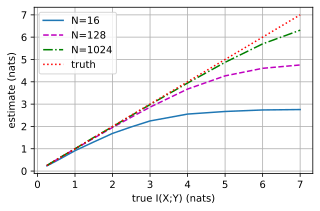

In [9]:
def pmi_gauss(x, y, rho):
    """Exact pmi(x, y) of the standard bivariate Gaussian, in nats."""
    c = 1 - rho**2
    return (-0.5 * onp.log(c) - (x**2 - 2 * rho * x * y + y**2) / (2 * c)
            + (x**2 + y**2) / 2)

def infonce_oracle(rng, rho, N, batches):
    """InfoNCE estimate with the *true* density-ratio critic."""
    vals = []
    for _ in range(batches):
        x, y = gauss_pair(rng, rho, N)
        f = pmi_gauss(x[:, None], y[None, :], rho)     # all N x N scores
        f -= f.max(axis=1, keepdims=True)              # stable log-softmax
        ll = onp.diag(f) - onp.log(onp.exp(f).sum(axis=1))
        vals.append(ll.mean() + onp.log(N))
    return onp.array(vals)

rng = onp.random.default_rng(7)
true_mi = onp.array([0.25, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 6, 7])
rhos = onp.sqrt(1 - onp.exp(-2 * true_mi))             # invert the closed form
ests = [onp.array([infonce_oracle(rng, r, N, 200 if N <= 128 else 50).mean()
                   for r in rhos]) for N in (16, 128, 1024)]
d2l.plot(true_mi, ests + [true_mi], 'true I(X;Y) (nats)', 'estimate (nats)',
         legend=['N=16', 'N=128', 'N=1024', 'truth'], figsize=(5, 3))

Each curve hugs the diagonal while the true mutual information is small, then
bends flat as it approaches its ceiling $\ln N$ ($\approx 2.77$, $4.85$, and
$6.93$ nats for the three batch sizes), *even though the critic is exact*.
No amount of architecture search or training fixes this; only a bigger $N$
raises the ceiling, and only logarithmically. This is the McAllester--Stratos
phenomenon in one picture.

Two readings of this hardness, before we proceed. Pessimistic: reported MI
numbers in the literature are not measurements; treat them as such.
Optimistic: representation learning never needed the *number*. Maximizing a
lower bound can shape features well even when the bound is slack: a hiker
can climb by always stepping uphill without ever knowing the summit's
altitude.

## Variational Bounds and InfoNCE

Mutual information involves the unknown densities of
the equation, so we cannot compute it, but we can *bound it
from below* by an expression involving only samples and an auxiliary model
(a "decoder" or a "critic"), then make the bound as tight as we can by
optimizing the auxiliary model. This turns estimation into optimization,
exactly the trick deep learning is good at, and tightening a lower bound on
shared information is precisely the training signal that contrastive methods
exploit. We derive the three classical bounds and then InfoNCE, the bound
modern practice rests on; @Poole.Oord.Alemi.ea.2019 give the unified
treatment.

### The Barber--Agakov Bound

The first bound replaces the unknown posterior with a model of it.

**Proposition (Barber--Agakov bound).** *For any conditional density
$q(x \mid y)$,*

$$I(X; Y) \geq H(X) + E_{(x,y) \sim P_{X,Y}}\left[\log q(x \mid y)\right],$$

*with equality if and only if $q(x \mid y) = p(x \mid y)$.*

**Proof.** Write $I(X; Y) = H(X) - H(X \mid Y)$ and insert the model:

$$
I(X; Y) - H(X) - E\left[\log q(x \mid y)\right]
= E\left[\log \frac{p(x \mid y)}{q(x \mid y)}\right]
= E_{y}\left[D_{\textrm{KL}}\!\left(p(\cdot \mid y) \,\|\, q(\cdot \mid y)\right)\right]
\geq 0
$$

by Gibbs' inequality, applied for each value of $y$ and averaged. Equality
holds iff the per-$y$ divergences all vanish, i.e., $q$ *is* the posterior.
$\blacksquare$

The bound [@Barber.Agakov.2003] is the information-theoretic reading of
an encoder--decoder: if a decoder can reconstruct $X$ from $Y$ with low
cross-entropy, the pair must share a lot of information. Its weakness is the
$H(X)$ term, which is unknown in exactly the situations where we need the
bound (though it is a constant: *maximizing* the bound never needs it). The
same proof with $q(x \mid y)/p(x)$ in place of $q(x \mid y)$ gives the
equivalent ratio form $I \geq E[\log\left(q(x \mid y)/p(x)\right)]$, which we
will reuse for InfoNCE.

### Donsker--Varadhan and MINE

The second bound dispenses with normalized models altogether: it
characterizes KL divergence, hence mutual information, as a supremum over
arbitrary *critic* functions $T(x, y)$, with no requirement that anything
integrate to one. This is the same convex-duality pattern that drives the
f-GAN construction in that section.

**Proposition (Donsker--Varadhan representation).** *For any distributions
$P, Q$ and any function $T$ with $E_Q[e^T] < \infty$,*

$$D_{\textrm{KL}}(P \| Q) \geq E_P[T] - \log E_Q\left[e^{T}\right],$$

*with equality if and only if $T = \log \frac{dP}{dQ} + c$ for a constant
$c$; taking the supremum over $T$ attains $D_{\textrm{KL}}(P \| Q)$ (both
statements for $P \ll Q$ with finite divergence)
[@Donsker.Varadhan.1983].*

**Proof.** Given $T$, define the *Gibbs distribution*
$g(x) = q(x)\, e^{T(x)} / Z$ with normalizer $Z = E_Q[e^T]$, the
distribution $Q$ "tilted" by the critic. Then

$$
D_{\textrm{KL}}(P \| Q) - \left(E_P[T] - \log Z\right)
= E_P\left[\log \frac{p}{q} - T + \log Z\right]
= E_P\left[\log \frac{p}{g}\right]
= D_{\textrm{KL}}(P \| G) \geq 0,
$$

by Gibbs' inequality (the eponymous coincidence is no accident). Equality
holds iff $P = G$, i.e., $p/q = e^{T}/Z$, i.e., $T = \log(p/q) + \log Z$.
$\blacksquare$

Specializing $P = P_{X,Y}$ and $Q = P_X \otimes P_Y$ bounds mutual
information: for any critic $T(x,y)$,

$$
I(X; Y) \geq E_{P_{X,Y}}[T] - \log E_{P_X \otimes P_Y}\left[e^{T}\right],
$$

where the second expectation is estimated by *shuffling*: pairing each $x$
with a $y$ drawn from a different example destroys the dependence and
samples the product of marginals. **MINE** (mutual information neural
estimation, @Belghazi.Baratin.Rajeshwar.ea.2018) is exactly this
bound with $T$ a neural network trained by gradient ascent on
the equation, plus a fix for the subtlety that the
$\log E[e^T]$ term makes naive minibatch gradients biased.

### The NWJ Bound and the Bias--Variance Spectrum

The logarithm in front of $E_Q[e^T]$ is the troublemaker: it couples all
samples in the batch and gives the DV bound its bias and, at high MI, its
exploding variance (the expectation of $e^T$ under $Q$ is carried by the
same rare events that the McAllester--Stratos argument warned about). The
tangent-line inequality $\log z \leq z/e$ (equality at $z = e$) trades
tightness for tractability: applying it to $Z = E_Q[e^T]$ in
the equation gives, for every critic $T$,

$$I(X; Y) \geq E_{P_{X,Y}}[T] - e^{-1}\, E_{P_X \otimes P_Y}\left[e^{T}\right],$$

the **NWJ bound** [@Nguyen.Wainwright.Jordan.2010], tight at
$T^* = 1 + \log\frac{dP}{dQ}$. Since $e^{-1} E_Q[e^T] = E_Q[e^{T-1}]$, the
right-hand side is exactly the f-GAN bound for the KL divergence,
$E_P[T] - E_Q[e^{T-1}]$, that Fenchel duality produced in
that section: this is where we meet that bound
again. Because no log-of-average appears, plain
minibatch estimates of the equation are unbiased for the bound
itself, but the $e^{T}$ term still has heavy tails, so the variance problem
survives. the figure sketches the resulting
family: estimators stacked under the true value, trading bias
for variance, with the contrastive bound we meet next sitting lowest but
steadiest.

![Variational lower bounds on mutual information, after Poole et al. (2019). Every estimator sits at or below the true-MI diagonal, and each fails in its own way as $I$ grows: InfoNCE is low-variance but capped at $\log N$; the decoder-based Barber--Agakov bound is low-variance but biased downward by its decoder's gap (it flattens); and the critic-based bounds lose control of their batch-to-batch spread (shaded band): NWJ's spread grows first while its mean falls below the truth, and the log-of-average in Donsker--Varadhan / MINE adds upward bias and the largest blow-up.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-it-mi-variational-bounds.svg)

### InfoNCE: Estimation as Classification

InfoNCE takes a different route to taming the partition
function: it embeds the problem in a *classification* task, the guessing
game we simulated in that section. Draw one positive pair and
$N-1$ negatives, score every candidate with a critic $f(x, y)$, and ask a
softmax to point at the positive. The **InfoNCE loss**
[@Oord.Li.Vinyals.2018] is the resulting cross-entropy,

$$\mathcal{L}_{\textrm{NCE}} = -E\left[\log \frac{e^{f(x, y_1)}}{\sum_{j=1}^{N} e^{f(x, y_j)}}\right],$$

where the expectation is over $(x, y_1) \sim P_{X,Y}$ and
$y_2, \ldots, y_N \sim P_Y$ i.i.d., and the associated mutual-information
*estimator* is the batch ceiling minus the loss,

$$\hat{I}_{\textrm{NCE}} = \log N - \mathcal{L}_{\textrm{NCE}}.$$

(Many papers, following @Oord.Li.Vinyals.2018, write the loss with a
$\frac{1}{N}$ inside the logarithm and a compensating $+\log N$ outside; the
two cancel, so that convention and the equation are the same
number.) Note what the loss *is*: a $k$-class categorical cross-entropy
with $k = N$, the same loss dissected in
that section and
that section, with classes that are *other examples
in the batch* rather than fixed labels. That is the entire engineering
appeal (this loss is exactly what deep-learning libraries optimize best),
and it is the loss
of CPC, SimCLR, and CLIP-style dual encoders, where $x$ and $y$ are two
views or two modalities of the same datum and the batch supplies the
negatives [@Oord.Li.Vinyals.2018; @radford2021learning].

![The InfoNCE game. Left: an anchor $x$ is scored by the critic $f$ against the positive $y^+$ drawn jointly with it and $N-1$ negatives drawn independently from the marginal. Right: a softmax over the $N$ scores must point at the positive; the resulting cross-entropy certifies $I(X;Y) \geq \log N - \mathcal{L}_{\textrm{NCE}}$, a bound that can never exceed $\log N$.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-it-infonce-pos-neg.svg)

the figure draws the game. The payoff is a theorem
[@Poole.Oord.Alemi.ea.2019]: small InfoNCE loss *certifies* mutual
information.

**Proposition (InfoNCE bound).** *For any critic $f$ and any $N \geq 1$,*

$$I(X; Y) \geq \hat{I}_{\textrm{NCE}} = \log N - \mathcal{L}_{\textrm{NCE}}, \qquad \textrm{and } \hat{I}_{\textrm{NCE}} \textrm{ never exceeds } \log N.$$

**Proof.** Write $V = (Y_1, \ldots, Y_N)$ for the whole bag of candidates,
where $(X, Y_1) \sim P_{X,Y}$ and the negatives $Y_{2:N} \sim P_Y$ are
independent of $(X, Y_1)$.

*Step 1: the negatives are free.* By the corollary to the chain rule,
independent side information adds nothing: $I(X; V) = I(X; Y_1)$.

*Step 2: a normalized variational model in disguise.* Define

$$
g(x, v) = \frac{e^{f(x, y_1)}}{\frac{1}{N}\sum_{j=1}^N e^{f(x, y_j)}}.
$$

Under the product distribution $p(x)\,p(v)$, where all $N$ candidates,
including $y_1$, are i.i.d. draws from $P_Y$, exchangeability of the $y_j$
makes each of the $N$ terms $E\big[e^{f(x,y_i)} / \frac{1}{N}\sum_j
e^{f(x,y_j)}\big]$ equal, so for every fixed $x$,

$$
E_{p(v)}\left[g(x, V)\right]
= \frac{1}{N}\sum_{i=1}^{N} E\left[\frac{e^{f(x, y_i)}}{\frac{1}{N}\sum_{j} e^{f(x, y_j)}}\right]
= E\left[\frac{\frac{1}{N}\sum_{i} e^{f(x, y_i)}}{\frac{1}{N}\sum_{j} e^{f(x, y_j)}}\right] = 1.
$$

Hence $q(v \mid x) = p(v)\, g(x, v)$ is a *bona fide* normalized conditional
distribution over bags.

*Step 3: Barber--Agakov on the bag.* The ratio form of
the equation applied to $(X, V)$ with the model $q(v \mid x)$
gives

$$
I(X; V) \geq E_{p(x, v)}\left[\log \frac{q(v \mid x)}{p(v)}\right]
= E\left[\log g(X, V)\right]
= \log N - \mathcal{L}_{\textrm{NCE}}.
$$

Combining with Step 1 proves the bound. For the ceiling, the softmax assigns
the positive a probability at most $1$, so
$\mathcal{L}_{\textrm{NCE}} \geq 0$ and the estimator
the equation is at most $\log N$. $\blacksquare$

The two halves of the proposition are the two faces of contrastive learning.
The bound explains *why it works*: driving the classification loss down
provably drives shared information up, and the optimal critic recovers the
density ratio $f^*(x,y) = \textrm{pmi}(x,y) + c(x)$ (Exercise 8;
[@Poole.Oord.Alemi.ea.2019]). The ceiling explains
*why batch size matters so much* in practice: with $N$ candidates the bound
simply cannot certify more than $\log N$ nats, which is why CPC, SimCLR, and
CLIP push toward enormous batches, and why even those raise the certifiable
information only logarithmically. One practical dial deserves naming: in
SimCLR-style systems the critic is a scaled cosine similarity between the
two embeddings, $f(x, y) = \textrm{sim}(z_x, z_y)/\tau$, and the
*temperature* $\tau$
[@Chen.Kornblith.Norouzi.ea.2020] is the same knob as the distillation
temperature of that section: lowering $\tau$
sharpens the softmax over candidates and concentrates the loss on the
hardest negatives.

Before training anything, let's compare all three bounds in their ideal
state, critics set to their optima exactly using the closed-form Gaussian
ratio, so that everything we see is a property of the *bounds*, not of
optimization. We use a batch of $N = 128$ and report the mean and standard
deviation across $200$ batches.

In [10]:
rng = onp.random.default_rng(3)
N, B = 128, 200
print('true I    DV (MINE)         NWJ              InfoNCE')
for tm in [0.5, 1.0, 2.0, 4.0, 6.0]:
    rho = onp.sqrt(1 - onp.exp(-2 * tm))
    dv, nwj, nce = [], [], []
    for _ in range(B):
        x, y = gauss_pair(rng, rho, N)
        joint = pmi_gauss(x, y, rho)               # T* on positive pairs
        # A random permutation leaves ~1 fixed point per batch of N=128, so
        # one "negative" is secretly a true pair; the O(1/N) contamination
        # is negligible next to the heavy tails probed here.
        prod = pmi_gauss(x, rng.permutation(y), rho)   # T* on shuffled pairs
        dv.append(joint.mean() - onp.log(onp.mean(onp.exp(prod))))
        nwj.append(joint.mean() + 1 - onp.mean(onp.exp(prod)))
        f = pmi_gauss(x[:, None], y[None, :], rho)
        f -= f.max(axis=1, keepdims=True)
        ll = onp.diag(f) - onp.log(onp.exp(f).sum(axis=1))
        nce.append(ll.mean() + onp.log(N))
    print(f'{tm:5.1f}   {onp.mean(dv):6.2f} +-{onp.std(dv):6.2f} '
          f'  {onp.mean(nwj):6.2f} +-{onp.std(nwj):6.2f} '
          f'  {onp.mean(nce):6.2f} +-{onp.std(nce):6.2f}')

true I    DV (MINE)         NWJ              InfoNCE
  0.5     0.50 +-  0.12     0.50 +-  0.12     0.50 +-  0.07
  1.0     1.01 +-  0.19     0.99 +-  0.22     1.00 +-  0.07
  2.0     1.93 +-  0.35     1.83 +-  0.97     1.94 +-  0.09


  4.0     3.79 +-  0.92     3.36 +-  1.18     3.67 +-  0.08
  6.0    23.22 +- 56.65     1.23 +- 11.74     4.61 +-  0.05


The table is the figure in numbers. At low
mutual information all three estimators are accurate and well-behaved. As
the truth climbs past $\ln N \approx 4.85$ nats, they fail in their
characteristic ways: InfoNCE stays steady (standard deviation a few
hundredths of a nat) but saturates at its ceiling; NWJ's batch-to-batch
spread grows first, exploding to many nats while its mean falls far below
the truth; and DV's log-of-average adds upward bias and the largest blow-up,
until single batches return values that are pure noise: at a true MI of $6$
nats its batch estimates average far *above* the truth with a spread of tens
of nats. With a perfect
critic. Estimator choice is a bias--variance decision, not a ranking.

### Experiment: Learning the Critic

Finally, let the critic be learned, as in practice. We train a small MLP
critic $f(x, y)$ with the InfoNCE loss on a correlated Gaussian pair with
$\rho = 0.99$, whose true mutual information
$-\tfrac{1}{2}\log(1 - 0.99^2) \approx 1.958$ nats we know exactly. The
data are generated once in NumPy with a fixed
seed; training uses batches of $N = 128$, and we then evaluate the trained
critic's InfoNCE bound at several evaluation batch sizes to watch the
$\log N$ ceiling and the approach to the truth in one table.

In [11]:
rho, n_pool = 0.99, 4096
data_rng = onp.random.default_rng(0)
x_tr, y_tr = (torch.tensor(a, dtype=torch.float32)
              for a in gauss_pair(data_rng, rho, n_pool))
x_ev, y_ev = (torch.tensor(a, dtype=torch.float32)
              for a in gauss_pair(data_rng, rho, n_pool))

torch.manual_seed(0)
critic = torch.nn.Sequential(
    torch.nn.Linear(2, 64), torch.nn.ReLU(),
    torch.nn.Linear(64, 64), torch.nn.ReLU(), torch.nn.Linear(64, 1))
opt = torch.optim.Adam(critic.parameters(), lr=1e-3)

def scores(x, y):
    """Matrix of critic scores f(x_i, y_j) for all pairs in a batch."""
    N = len(x)
    xy = torch.stack([x.reshape(N, 1).expand(N, N),
                      y.reshape(1, N).expand(N, N)], dim=-1)
    return critic(xy.reshape(-1, 2)).reshape(N, N)

N = 128
for step in range(400):
    idx = torch.tensor(data_rng.choice(n_pool, N, replace=False))
    f = scores(x_tr[idx], y_tr[idx])
    loss = (torch.logsumexp(f, dim=1) - f.diag()).mean()
    opt.zero_grad(); loss.backward(); opt.step()

with torch.no_grad():
    for N_ev in [2, 8, 32, 128]:
        vals = [(scores(x_ev[i:i + N_ev], y_ev[i:i + N_ev]).diag()
                 - torch.logsumexp(scores(x_ev[i:i + N_ev],
                                          y_ev[i:i + N_ev]), dim=1)
                 ).mean().item()
                for i in range(0, n_pool, N_ev)]
        print(f'N = {N_ev:4d}: ln N = {onp.log(N_ev):.3f}, '
              f'InfoNCE bound = {onp.log(N_ev) + onp.mean(vals):.3f} nats')
print(f'true I(X;Y) = {-0.5 * onp.log(1 - rho**2):.3f} nats')

N =    2: ln N = 0.693, InfoNCE bound = 0.570 nats
N =    8: ln N = 2.079, InfoNCE bound = 1.407 nats


N =   32: ln N = 3.466, InfoNCE bound = 1.762 nats
N =  128: ln N = 4.852, InfoNCE bound = 1.888 nats
true I(X;Y) = 1.959 nats


A two-layer critic trained for $400$ steps recovers the structure almost
perfectly. Reading the table against the truth of $1.958$ nats: at
$N = 2$ the bound is pinned below its ceiling $\ln 2 \approx 0.693$; at
$N = 8$ the ceiling ($\approx 2.08$) finally clears the truth and the bound
jumps to about $1.4$; and by $N = 128$ the learned critic certifies about
$1.89$ nats, within $0.07$ of the truth, the residual being the cost of an
imperfect critic and finite evaluation data. The same critic, the same data:
only the number of negatives changed. Batch size sets the resolution of the
instrument.

## The Information Bottleneck and the Limits of Mutual Information

We close with the principle that joins this section's two themes, what
representations preserve and what we can measure, into a single objective,
and with an assessment of where its empirical support stands.

### Compression with a Purpose: the IB Lagrangian

What makes a representation $Z$ of an input $X$ *good* for predicting a
label $Y$? The *information bottleneck* (IB) principle
[@Tishby.Pereira.Bialek.1999] answers with two mutual informations: a
good $Z$ keeps little of $X$ (it *compresses*) while keeping much of $Y$ (it
*predicts*). Over stochastic encoders $p(z \mid x)$, minimize the Lagrangian

$$\min_{p(z \mid x)}\; I(X; Z) - \beta\, I(Y; Z).$$

The data-processing inequality is what makes this well-posed: since
$Y \to X \to Z$ is a Markov chain (the encoder sees only $X$), we always
have $I(Y; Z) \leq \min\{I(X; Y),\, I(X; Z)\}$: the representation can
never know more about the label than the input does, and predicting well
forces $Z$ to retain input information. The multiplier $\beta$ sets the
tradeoff: as $\beta \to 0$ the optimum collapses to an uninformative $Z$
(maximal compression), as $\beta \to \infty$ it retains everything relevant
(and, en route, recovers sufficient statistics in the sense of
that section); sweeping $\beta$
traces a frontier in the *information plane* with coordinates
$(I(X;Z),\, I(Y;Z))$. Rate--distortion theory [@Shannon.1959] is the
special case where
"relevance" is a hand-chosen distortion measure; IB lets the label define
relevance instead. The *deep variational information bottleneck* (VIB)
[@Alemi.Fischer.Dillon.ea.2017] makes the equation
trainable by bounding both terms with the machinery we just built: a
Barber--Agakov-style decoder bound for $I(Y;Z)$ from below and a variational
upper bound for $I(X;Z)$, the same replace-the-intractable-posterior pattern
as the ELBO of that section: another reminder that in
deep learning, mutual informations are optimized through bounds, not
computed. The frontier this
tradeoff traces is shown in the figure.

![The information plane of the Gaussian bottleneck with $\rho = 0.9$: the concave frontier traces the best attainable $I(Y;Z)$ at each compression level $I(X;Z)$, the shaded region above it is infeasible, and the dashed ceiling is the data-processing limit $I(X;Y) = -\tfrac{1}{2}\log(1-\rho^2) \approx 0.830$ nats. Dots mark the operating points the multiplier $\beta$ selects; for $\beta \leq 1/\rho^2$ the optimum collapses to the origin.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-it-ib-tradeoff.svg)

### The Information Plane: a Gaussian Bottleneck in Closed Form

Rather than train a VIB (two stacked variational bounds would put us two
bounds away from anything checkable), we exhibit the IB tradeoff in a model
where every quantity is exact [@Chechik.Globerson.Tishby.ea.2005]. Let
$(X, Y)$ be our standard Gaussian pair with $\rho = 0.9$, so
$I(X; Y) \approx 0.830$ nats, and let the encoder be a noisy channel

$$
Z = X + \sigma\, \epsilon, \qquad \epsilon \sim \mathcal{N}(0, 1),
$$

with the noise scale $\sigma$ as the compression knob. Both informations
follow from the Gaussian anchor the equation: the correlations
are $\rho_{XZ}^2 = 1/(1 + \sigma^2)$ and
$\rho_{YZ}^2 = \rho^2/(1 + \sigma^2)$, so

$$
I(X; Z) = \tfrac{1}{2}\log\left(1 + \sigma^{-2}\right), \qquad
I(Y; Z) = -\tfrac{1}{2}\log\left(1 - \frac{\rho^2}{1 + \sigma^2}\right).
$$

In this scalar Gaussian family the noise level is the *only* degree of
freedom, so sweeping $\sigma$ traces the family's entire curve; that this
curve is the *optimal* frontier over all encoders $p(z \mid x)$ is the
Gaussian information bottleneck theorem of
[@Chechik.Globerson.Tishby.ea.2005]. Minimizing the Lagrangian
the equation over $\sigma$ for
each $\beta$ picks out one operating point on the frontier.

beta =  1.0: I(X;Z) = 0.000, I(Y;Z) = 0.000 nats
beta =  1.5: I(X;Z) = 0.382, I(Y;Z) = 0.284 nats
beta =  2.0: I(X;Z) = 0.731, I(Y;Z) = 0.487 nats
beta =  4.0: I(X;Z) = 1.283, I(Y;Z) = 0.689 nats
beta = 16.0: I(X;Z) = 2.080, I(Y;Z) = 0.798 nats


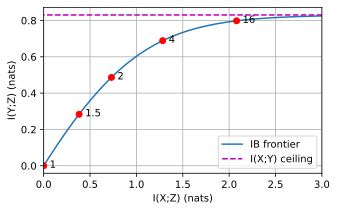

In [12]:
rho = 0.9
sigma = onp.logspace(-2, 2, 401)            # noise scale: the beta knob
I_xz = 0.5 * onp.log(1 + sigma**-2)         # compression cost
I_yz = -0.5 * onp.log(1 - rho**2 / (1 + sigma**2))  # predictive value
I_xy = -0.5 * onp.log(1 - rho**2)

d2l.plot(I_xz, [I_yz, onp.full_like(I_xz, I_xy)], 'I(X;Z) (nats)',
         'I(Y;Z) (nats)', legend=['IB frontier', 'I(X;Y) ceiling'],
         xlim=[0, 3], figsize=(5, 3))
for beta in [1.0, 1.5, 2.0, 4.0, 16.0]:
    i = onp.argmin(I_xz - beta * I_yz)      # IB Lagrangian on the grid
    d2l.plt.plot(I_xz[i], I_yz[i], 'ro')
    d2l.plt.annotate(f'{beta:g}', (I_xz[i], I_yz[i]),
                     textcoords='offset points', xytext=(6, -2))
    print(f'beta = {beta:4.1f}: I(X;Z) = {I_xz[i]:.3f}, '
          f'I(Y;Z) = {I_yz[i]:.3f} nats')

The frontier rises steeply from the origin (the first fraction of a nat of
retained input information buys label information at the best exchange rate,
$\rho^2$ nats per nat), then flattens as $I(Y;Z)$ approaches its DPI ceiling
$I(X;Y)$: keeping ever more of $X$ buys less and less about $Y$. The marked
points show the $\beta$ knob at work, including the degenerate regime: for
$\beta \leq 1/\rho^2 \approx 1.23$ the exchange rate never beats the price
and the optimum is total collapse, $I(X;Z) = I(Y;Z) = 0$; beyond it, rising
$\beta$ slides the operating point up the frontier. A deep VIB does exactly
this on real data (encoder noise instead of $\sigma$, variational bounds
instead of closed forms), and its $\beta$-sweep traces a noisy version of
the same curve.

### The Compression-Phase Debate

The information plane also hosts one of deep learning's livelier disputes.
@Shwartz-Ziv.Tishby.2017 plotted estimated $(I(X;Z), I(Y;Z))$
trajectories of ordinary classifiers *during training* and reported a
two-phase dynamic, a fast *fitting* phase (both informations rise) followed
by a long *compression* phase ($I(X;Z)$ falls while $I(Y;Z)$ holds),
proposed as the mechanism by which deep networks generalize.
@Saxe.Bansal.Dapello.ea.2018 re-examined the claim and found the
compression phase to be largely an artifact: it appears with saturating
activations (tanh squashes activations into the bins' edges, which the
binned MI estimator reads as compression) and disappears with ReLU networks,
which generalize just as well without any measured compression. Worse, for
a *deterministic* network with continuous inputs, $I(X; Z)$ is in fact
infinite or constant (the singular case flagged at the definition
the equation): whatever the plotted trajectories track, it is
a property of the binning, not a mutual information. Where the debate
stands: the
IB *objective* the equation is well-posed for explicitly
stochastic encoders and trains well (VIB improves robustness and
calibration in practice), but the claim that standard training *implicitly*
performs IB compression remains unsettled, and the dispute itself is a case
study in how treacherous MI estimation is, which is precisely this
section's second theme.

### What Mutual Information Guarantees: Fano's Inequality

One guarantee explains why anyone wants high mutual information in the
first place: enough shared information is a *prerequisite* for accurate
prediction.

**Proposition (Fano's inequality).** *Let $X$ take values in a set of size
$k$, and let $\hat{X} = g(Y)$ be any estimate of $X$ computed from $Y$, with
error probability $P_e = P(\hat{X} \neq X)$. Then*

$$H_b(P_e) + P_e \log(k - 1) \geq H(X \mid Y) = H(X) - I(X; Y),$$

*where $H_b$ is the binary entropy in nats* [@Cover.Thomas.1999].

**Proof.** Let $E = \mathbf{1}_{\hat{X} \neq X}$ be the error indicator and
expand $H(E, X \mid \hat{X})$ by the chain rule in both orders. One order:
$H(E, X \mid \hat{X}) = H(X \mid \hat{X})$, since $E$ is a function of
$(X, \hat{X})$. The other:
$H(E, X \mid \hat{X}) = H(E \mid \hat{X}) + H(X \mid E, \hat{X})
\leq H_b(P_e) + P_e \log(k-1)$, because conditioning cannot raise entropy
($H(E \mid \hat{X}) \leq H(E) = H_b(P_e)$, since $I(E; \hat{X}) \geq 0$),
and given $E$: when $E = 0$, $X = \hat{X}$ is known (zero entropy), and
when $E = 1$ (probability $P_e$), $X$ ranges over at most $k - 1$ values.
Finally $X \to Y \to \hat{X}$ is a Markov chain, so the data-processing
inequality gives $I(X; \hat{X}) \leq I(X; Y)$, i.e.,
$H(X \mid \hat{X}) \geq H(X \mid Y)$. Chaining the three displays proves the
claim. $\blacksquare$

Fano converts information into a floor on achievable error: no
representation, classifier, or amount of compute can beat it. It quantifies
the "prerequisite" reading of contrastive learning: features that support
accurate downstream classification *must* carry high mutual information with
the label. The numbers are sobering when combined with this section's
estimation ceiling:

In [13]:
k, p_e = 1000, 0.05
H_b = lambda p: -p * onp.log(p) - (1 - p) * onp.log(1 - p)
need = onp.log(k) - H_b(p_e) - p_e * onp.log(k - 1)
print(f'{p_e:.0%} error on {k} balanced classes needs '
      f'I(X;Y) >= {need:.3f} nats')
print(f'certifying that much MI needs N > e^I = {onp.exp(need):.0f} samples')

5% error on 1000 balanced classes needs I(X;Y) >= 6.364 nats
certifying that much MI needs N > e^I = 581 samples


Five percent error on a thousand balanced classes requires at least
$6.36$ nats of label information; taking the $\log N$ ceiling at face
value, *certifying* that much mutual information needs
$N \gtrsim e^{I} \approx 581$ samples per batch. The
two halves of this section are one subject.

### What Mutual Information Estimates Can and Cannot Tell You

Let's consolidate the section's findings into usage guidance, because mutual
information is at once indispensable and routinely over-read.

* **A neural bound is not a direct measurement.** The high-dimensional neural
  estimators discussed above (InfoNCE, NWJ, DV/MINE, and decoder bounds) are
  variational bounds estimated from batches and often optimized with imperfect
  critics: noisy estimates of bounds. Histogram, kernel, and nearest-neighbor
  estimators are not variational lower bounds, although they have their own
  dimensionality, bias, and tuning problems. The $\log N$
  ceiling caps what any of them can certify, and past the ceiling an
  estimator returns either a saturated number (InfoNCE) or an exploding one
  (DV/NWJ).
* **The objective can be good even when the number is bad.**
  @Tschannen.Djolonga.Rubenstein.ea.2020 show that downstream
  representation quality correlates poorly with the tightness of the MI
  bound being maximized: looser bounds sometimes yield *better*
  representations, and InfoNCE's success owes as much to the inductive
  biases of the critic architecture and the choice of views as to its
  information content. Maximizing an MI bound is a useful *training signal*
  wrapped in a partly-aesthetic theory, and the wrapping should not be
  mistaken for a guarantee.
* **Invariances cut both ways.** MI's reparameterization invariance makes it
  the right notion of dependence and simultaneously the wrong target for
  easy estimation; any pipeline that needs a trustworthy dependence number
  on high-dimensional data should confront that tension directly (e.g., by
  validating its estimator on a known-MI synthetic pair, as we did here).
* **What survives the caveats** is exactly what we proved: the definitions
  and their calculus, the data-processing inequality, Fano's floor, the
  bounds' validity as *bounds*, and the closed-form anchors used to test
  estimators. Build on those, and treat everything else as engineering.

## Summary

* Mutual information $I(X;Y) = D_{\textrm{KL}}(P_{X,Y} \| P_X \otimes P_Y)$
  measures how far a pair of variables is from independence. It is
  symmetric, non-negative, zero exactly at independence, equals
  $H(X) - H(X \mid Y) = H(X) + H(Y) - H(X,Y)$, and is invariant under
  invertible reparameterization of either variable; unlike correlation, it
  detects *any* dependence.
* The Gaussian pair gives the closed-form anchor
  $I = -\tfrac{1}{2}\log(1 - \rho^2)$; pointwise mutual information scores
  individual co-occurrences and powers collocation mining in NLP.
* The chain rule $I(X; Y, Z) = I(X;Z) + I(X; Y \mid Z)$ yields the
  data-processing inequality: along a Markov chain $X \to Y \to Z$,
  $I(X;Z) \leq I(X;Y)$. Processing never creates information;
  representations only lose it.
* Estimating MI is statistically hard: any distribution-free,
  high-confidence lower bound from $N$ samples is capped near $\log N$
  nats (McAllester--Stratos), a ceiling that even a perfect critic hits.
* Practical estimators are variational lower bounds: Barber--Agakov
  (decoder), Donsker--Varadhan/MINE and NWJ (critics), and InfoNCE
  (contrastive classification, a categorical cross-entropy). InfoNCE
  certifies $I \geq \log N - \mathcal{L}$, is low-variance but saturates at
  $\log N$; DV/NWJ are tighter in expectation but their variance explodes
  at high MI.
* The information bottleneck $\min I(X;Z) - \beta\, I(Y;Z)$ frames good
  representation as a compression--prediction tradeoff, made trainable by
  the same variational bounds (VIB); the claim that ordinary training
  implicitly compresses is contested (Saxe et al.). Fano's inequality is
  the guarantee that survives: low prediction error *requires* high mutual
  information.

## Exercises

1. Prove the discrete bounds $\max\{H(X), H(Y)\} \leq H(X, Y) \leq
   H(X) + H(Y)$ from the chain rule and the properties of (conditional)
   entropy. Which inequality fails for differential entropy, and why?
1. Compute $I(X;Y)$ by hand for the joint p.m.f.
   $p_{X,Y} = \left(\begin{smallmatrix} 0.3 & 0.2 \\ 0.1 & 0.4
   \end{smallmatrix}\right)$: form the marginals, evaluate the pointwise
   mutual information at each cell, and average. Check your answer against
   the `mutual_information` function.
1. Derive the Gaussian formula the equation directly by
   integrating the equation (without the entropy
   identities). How large must $\rho$ be for $I(X;Y)$ to exceed the
   certification ceiling of a batch of $N = 256$?
1. Construct a pair of *discrete* random variables with zero correlation
   but positive mutual information, and verify both numerically. Then prove
   that for jointly Gaussian variables, zero correlation does imply
   $I = 0$.
1. (Data-processing) Let $X \to Y \to Z$ with a *deterministic* second step
   $Z = g(Y)$. Show $I(X; g(Y)) \leq I(X; Y)$ with equality when $g$ is
   invertible, and give an example where $g$ is not invertible yet equality
   still holds. Can post-processing by any randomized $g$ ever increase
   mutual information?
1. (Synergy) Conditioning can *create* dependence: let $X, Y$ be
   independent fair bits and $Z = X \oplus Y$ (exclusive or). Show
   $I(X; Y) = 0$ but $I(X; Y \mid Z) = \ln 2$. Why does this not contradict
   the data-processing inequality?
1. Derive the Barber--Agakov bound the equation from
   $I = H(X) - H(X \mid Y)$ and Gibbs' inequality, and show that the gap of
   the bound equals $E_y[D_{\textrm{KL}}(p(\cdot \mid y) \| q(\cdot \mid
   y))]$.
1. Show from the equation that
   $\mathcal{L}_{\textrm{NCE}} \geq 0$, conclude that the InfoNCE estimator
   the equation can never exceed $\log N$, and explain in one paragraph
   why increasing the batch size tightens the bound. What does the optimal
   critic look like?
1. For the scalar Gaussian bottleneck, derive the critical value
   $\beta^* = 1/\rho^2$ below which the IB optimum collapses to an
   uninformative $Z$, by examining the slope of the frontier at
   $I(X;Z) = 0$. Characterize the optimal $Z$ as $\beta \to \infty$.
1. Using Fano's inequality the equation and the $\log N$ ceiling
   taken at face value, estimate the smallest contrastive batch size that
   could in principle certify enough mutual information for $1\%$ error on
   a balanced $10{,}000$-class problem. Then design (and run) a sanity check for any
   MI estimator using a known-MI Gaussian pair.

[Discussions](https://d2l.discourse.group/)